### Quadratic equation roots

In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal

In [1]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation : str
    discriminant : float
    result: str

NameError: name 'TypedDict' is not defined

In [9]:
def show_equation(state : QuadState) -> QuadState:

    equation = f"{state['a']}x2({state['b']}x{state['c']})"
    
    return {'equation':equation}

In [10]:
def calculate_discriminant(state : QuadState) -> QuadState:

    discriminant = state['b']**2 - (4*state['a']*state['c'])

    return {'discriminant': discriminant}


In [13]:
def real_roots(state:QuadState) ->QuadState:
    
    root1= (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
    root2= (-state['b'] - state['discriminant']**0.5)/(2*state['a'])

    result = f'The roots are {root1} and {root2}'

    return {'result':result}

In [14]:
def repeated_roots(state:QuadState) ->QuadState:
    
    root= (-state['b'])/(2*state['a'])

    result = f'The roots are {root}'

    return {'result':result}

In [15]:
def no_real_roots(state:QuadState) ->QuadState:

    result = f'The no real roots'

    return {'result':result}

In [16]:
def check_condition(state: QuadState) -> Literal["real_roots","repeated_roots","no_real_roots"]:

    if state["discriminant"]>0:
        return "real_roots"
    elif state["discriminant"]==0:
        return "repeated_roots"
    else:
        return "no_real_roots"

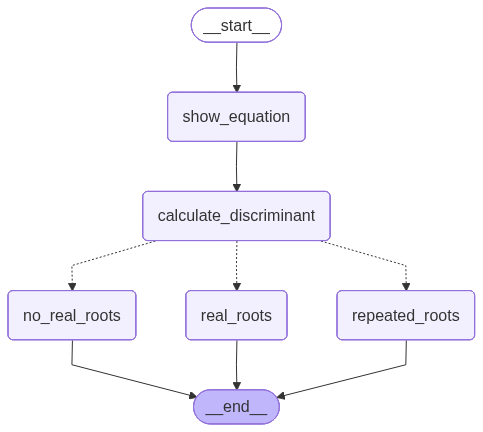

In [18]:
graph = StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)


#edges
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant',check_condition)

graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)

workflow = graph.compile()

workflow




In [21]:
initial_state={'a':2,'b':4,'c':2}
final_state = workflow.invoke(initial_state)
final_state

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x2(4x2)',
 'discriminant': 0,
 'result': 'The roots are -1.0'}

### LLM based review Handling workflow

In [1]:
import os
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
load_dotenv()

True

In [2]:
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
class SentimentSchema(BaseModel):

    sentiment: Literal["possitive","negative"] = Field(description='sentiment about the review')

In [13]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [5]:
#clean the and get jeson output
import re

def extract_json_from_markdown(text: str) -> str:
    match = re.search(r"```(?:json)?\s*({.*})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)
    return text  # fallback if not wrapped

In [6]:
import json
import ast
from langchain_core.output_parsers import PydanticOutputParser
# response want in json
parser = PydanticOutputParser(pydantic_object=SentimentSchema)
format_instructions = parser.get_format_instructions()

prompt = f'What is the sentiment of the following reivew - the software too good \n Format instructions:{format_instructions}'


# After llm.invoke(prompt).content
raw_output = llm.invoke(prompt).content
json_output = extract_json_from_markdown(raw_output)
#result = json.loads(str(json_output))
result = ast.literal_eval(str(json_output))
result

{'sentiment': 'possitive'}

In [7]:
class ReviewState(TypedDict):

    review : str
    sentiment : Literal["possitive","negative"]
    diagnosis : dict
    response : str

In [8]:
def find_sentiment(state: ReviewState) -> ReviewState:
    
    prompt = f'What is the sentiment of the following reivew \n {state["review"]} \n Format instructions:{format_instructions}'

    raw_output = llm.invoke(prompt).content
    json_output = extract_json_from_markdown(raw_output)
    result = ast.literal_eval(str(json_output))
    
    return {'sentiment' : result['sentiment'] }


In [11]:
def check_sentiment(state: ReviewState) -> Literal["possitive_responce","run_diagnosis"]:

    if state["sentiment"] == "possitive":
        return "possitive_responce"
    else:
        return "run_diagnosis"

In [12]:
def possitive_responce(state: ReviewState):

    prompt = f""" write a warm thank-you massage in responce to this reivew:
    \n\n "{state['review']}" \n\n Also, kindly ask the user to leave the feedback on our website."""

    responce = llm.invoke(prompt).content

    return {'responce' : responce}

In [21]:
parser1 = PydanticOutputParser(pydantic_object=DiagnosisSchema)
format_instructions1 = parser1.get_format_instructions()

def run_diagnosis(state: ReviewState):

     prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency. \n {format_instructions1}"""
     
     raw_output = llm.invoke(prompt).content
     json_output = extract_json_from_markdown(raw_output)
     result = ast.literal_eval(str(json_output))
    
     return {'diagnosis' : result}


In [22]:
def negative_responce(state: ReviewState):
    
    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
            The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
            Write an empathetic, helpful resolution message."""
    
    response = llm.invoke(prompt).content

    return {'response': response}

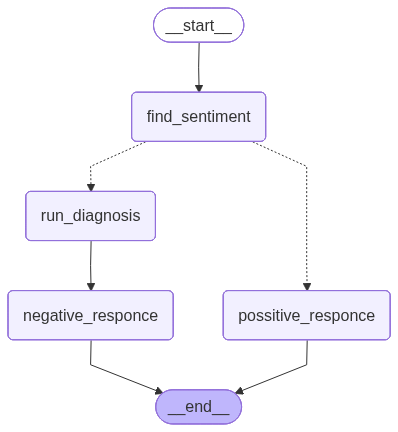

In [23]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('possitive_responce',possitive_responce)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_responce',negative_responce)

graph.add_edge(START, "find_sentiment")

graph.add_conditional_edges('find_sentiment',check_sentiment)

graph.add_edge("possitive_responce", END)

graph.add_edge("run_diagnosis", "negative_responce")
graph.add_edge('negative_responce',END)

workflow = graph.compile()

workflow


In [25]:
initial_state = { 'review' : "I want the emaerjancy dilevery they can you late for the laptop, bease it important to today in meeting."}
final_state = workflow.invoke(initial_state)
final_state

{'review': 'I want the emaerjancy dilevery they can you late for the laptop, bease it important to today in meeting.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Support',
  'tone': 'frustrated',
  'urgency': 'high'},
 'response': "I'm so sorry to hear that you're experiencing a support issue and feeling frustrated. I can imagine how that must be affecting you, and I want to assure you that I'm here to help. I've marked your issue as high priority, and I'm committed to resolving it as quickly as possible.\n\nCan you please provide me with more details about the issue you're facing? This will help me better understand the problem and work towards a solution. Additionally, I'd like to offer you a few options to get started:\n\n1. I can try to troubleshoot the issue with you over this chat.\n2. If needed, I can escalate the issue to our advanced support team for further assistance.\n3. Alternatively, I can provide you with a temporary workaround or a fix that you can apply im